In [64]:
import sqlite3
import os
import shutil

In [65]:
import pandas as pd
import matplotlib as mp 

In [94]:
DB_FILE_original = '../../data/db_info_articles_test.sqlite3'
DB_FILE_rerun_titles = './db_small_titles.sqlite3'

In [95]:
# Connect to the db
conn_orr = sqlite3.connect(DB_FILE_original)
conn_rerun_titles = sqlite3.connect(DB_FILE_rerun_titles)
sql_query = '''
SELECT am.pmcid, am.article_title, s.methods
FROM article_metadata am
INNER JOIN sections s ON am.pmcid = s.pmcid
'''

In [107]:
# Get the metadata from the db
c = conn_orr.cursor()
# Execute a SELECT query to retrieve the pmcid values
c.execute(sql_query)
# Fetch all the pmcid values and store them in a list
df_title_original =  pd.DataFrame([row for row in c.fetchall()])
c.close()

In [108]:
# Get the metadata from the db
c = conn_rerun_titles.cursor()
# Execute a SELECT query to retrieve the pmcid values
c.execute(sql_query)
# Fetch all the pmcid values and store them in a list
df_title_rerun =  pd.DataFrame([row for row in c.fetchall()])
c.close()

In [109]:
df_title_original['title_word_count_original'] =  df_title_original[1].apply(lambda x: len(str(x).split()))
df_title_original['method_word_count_original'] =  df_title_original[2].apply(lambda x: len(str(x).split()))
df_title_original = df_title_original.rename(columns={1:'original_title', 2:'original_method'})

<Axes: ylabel='Frequency'>

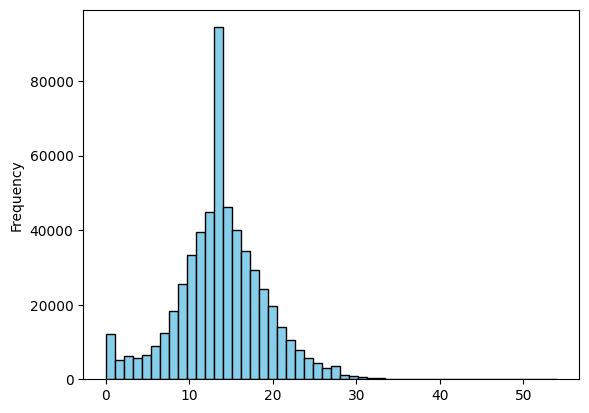

In [110]:
df_title_original['title_word_count_original'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')

<Axes: ylabel='Frequency'>

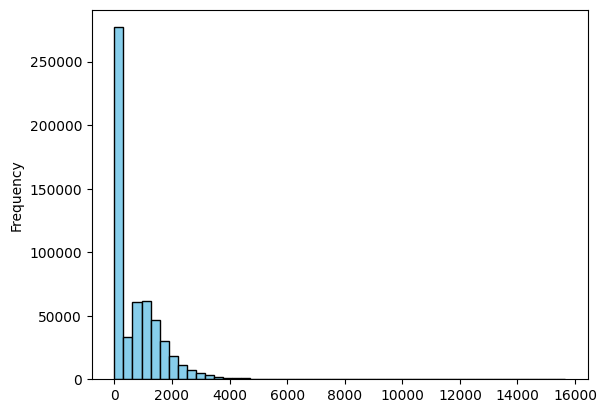

In [111]:
df_title_original['method_word_count_original'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')

In [112]:
#df_title_original[df_title_original['title_word_count_original'] < 5][0].to_csv('list_pmcid_to_redo.txt', index=False)

In [113]:
# Copy files that have lower than 5 title name
def copy_files(source_folder, destination_folder, filename_list_path):
    # Read the list of filenames from the text file
    with open(filename_list_path, 'r') as file:
        filenames_to_copy = [line.strip() for line in file]

    # Ensure the destination folder exists, create it if not
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    # Iterate through the filenames and copy them to the destination folder
    for filename in filenames_to_copy:
        filename = f"{filename}.xml"
        source_path = os.path.join(source_folder, filename)
        destination_path = os.path.join(destination_folder, filename)

        try:
            shutil.copy2(source_path, destination_path)
            #print(f"File {filename} copied successfully.")
        except FileNotFoundError:
            print(f"File {filename} not found in the source folder.")
        except Exception as e:
            print(f"Error copying file {filename}: {e}")

# Example usage
source_folder = '../../data/articles_human'
destination_folder = './small_titles/'
filename_list_path = 'list_pmcid_to_redo.txt'

#copy_files(source_folder, destination_folder, filename_list_path)


In [114]:
# Load the data from the new ran titles
df_title_rerun['title_word_count_rerun'] =  df_title_rerun[1].apply(lambda x: len(str(x).split()))
df_title_rerun['method_word_count_rerun'] =  df_title_rerun[2].apply(lambda x: len(str(x).split()))

df_title_rerun = df_title_rerun.rename(columns={1:'rerun_title', 2:'rerun_method'})
df_title_rerun

,0,rerun_title,rerun_method,title_word_count_rerun,method_word_count_rerun
0,PMC9563189,Protocol for detecting Yersinia pseudotubercul...,None,12,1
1,PMC8418983,Reduction of Tissue Na + Accumulation After Re...,None,9,1
2,PMC9837974,Disruption of DDX53 coding sequence has limite...,None,13,1
3,PMC2785483,Identification of MAMDC1 as a Candidate Suscep...,Materials and Methods Subjects and Samples Eth...,13,1516
4,PMC2214798,A Prevalent Variant in PPP1R3A Impairs Glycoge...,None,17,1
...,...,...,...,...,...
29275,PMC5506530,Cigarette smoke differentially affects IL ‐13‐...,None,13,1
29276,PMC4784550,Common Polymorphisms in IL-27 Genes May Contri...,Material and Methods Search strategy Potential...,18,484
29277,PMC8457475,LTA4H rs2660845 association with montelukast r...,Methods Study design Asthmatic patients treate...,11,2012
29278,PMC4769270,DNAH6 and Its Interactions with PCD Genes in H...,Materials and Methods Ethics statement Patient...,13,1671


In [115]:
df_title_rerun[''].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')

KeyError: ''

In [116]:
df_title_rerun[df_title_rerun['title_word_count_rerun'] < 2]

,0,rerun_title,rerun_method,title_word_count_rerun,method_word_count_rerun
3585,PMC2173811,Cast,Materials and methods Purification of synaptic...,1,1990
4756,PMC2172594,SPOTS,"Materials and methods Patients, cell lines, pl...",1,806
6131,PMC2233697,Cftr,MATERIALS AND METHODS Mutagenesis The CFTR mut...,1,804
7920,PMC6112880,STROBE,None,1,1
8517,PMC2172650,EpsinR,Materials and methods Protein expression and p...,1,1194
9699,PMC2172304,Borealin,Materials and methods Cloning and expression o...,1,867
10497,PMC2175099,Ggas,Materials and Methods Nucleic Acid Manipulatio...,1,1703
11609,PMC3206570,Zasp,Materials and Methods Antibodies A cDNA fragme...,1,2077
11783,PMC5638153,CEDNIK,Materials and Methods The institutional review...,1,228
11809,PMC2172532,XBP1,Materials and methods Plasmids pBMN-I-GFP (Dr....,1,1013


In [117]:
df_title_rerun[~df_title_rerun['rerun_method'].isna()]

,0,rerun_title,rerun_method,title_word_count_rerun,method_word_count_rerun
3,PMC2785483,Identification of MAMDC1 as a Candidate Suscep...,Materials and Methods Subjects and Samples Eth...,13,1516
7,PMC8657529,Strategies associated with COVID ‐19 vaccine c...,METHODS Study design and participants We selec...,11,1454
9,PMC5493610,Quantitative Proteomics Analysis of Plasmodium...,Methods Ethics statement This study was approv...,19,2195
11,PMC8115215,Bacteroides Fragilis Polysaccharide A Ameliora...,Materials LPS and TAK-242 were purchased from ...,15,1016
12,PMC3694110,Assessment of SLX4 Mutations in Hereditary Bre...,Materials and Methods DNA Samples Genomic DNA ...,8,792
...,...,...,...,...,...
29273,PMC9685555,Coexistence of bla NDM–5 and tet (X4) in inter...,Materials and methods Sample collection and id...,19,751
29276,PMC4784550,Common Polymorphisms in IL-27 Genes May Contri...,Material and Methods Search strategy Potential...,18,484
29277,PMC8457475,LTA4H rs2660845 association with montelukast r...,Methods Study design Asthmatic patients treate...,11,2012
29278,PMC4769270,DNAH6 and Its Interactions with PCD Genes in H...,Materials and Methods Ethics statement Patient...,13,1671


In [118]:
merged_df = pd.merge(df_title_original, df_title_rerun, on=0, how='inner')

In [119]:
merged_df['diff_titles'] = merged_df['title_word_count_rerun'] - merged_df['title_word_count_original']
merged_df['diff_methods'] = merged_df['method_word_count_rerun'] - merged_df['method_word_count_original']

<Axes: ylabel='Frequency'>

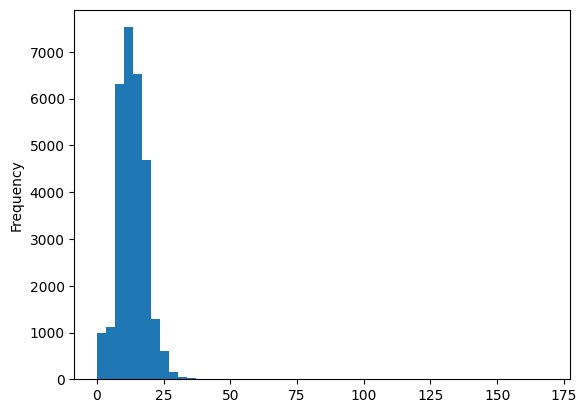

In [120]:
merged_df['diff_titles'].plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

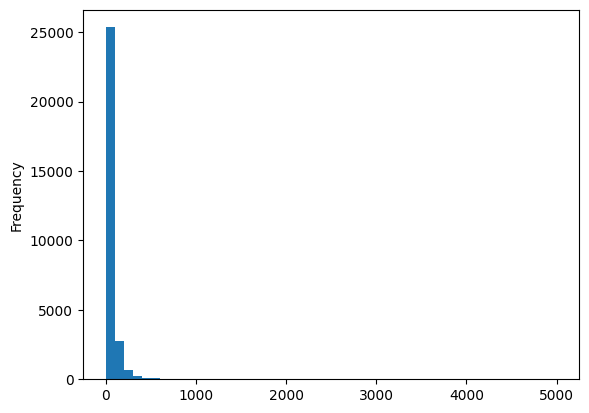

In [121]:
merged_df['diff_methods'].plot(kind='hist', bins=50)